<a href="https://colab.research.google.com/github/Shuhan78/news_index_and_predict/blob/main/stock_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📥 正在下載並設定繁體中文字型 (思源黑體)...
🔍 開始搜尋股票代號: 2308 ...
✅ 成功獲取股價資料！(市場別: 上市 (TSE))

📰 開始嘗試透過 Google RSS 獲取【台達電】的新聞 ...


/tmp/ipykernel_1066/2387609773.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_tw = yf.download(f"{stock_id}.TW", period="1mo", progress=False)


✅ 成功取得 100 則新聞
⏳ 載入進階 AI 語意分析模型中 (首次執行約需 15 秒)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

🧠 正在逐筆分析新聞情緒...


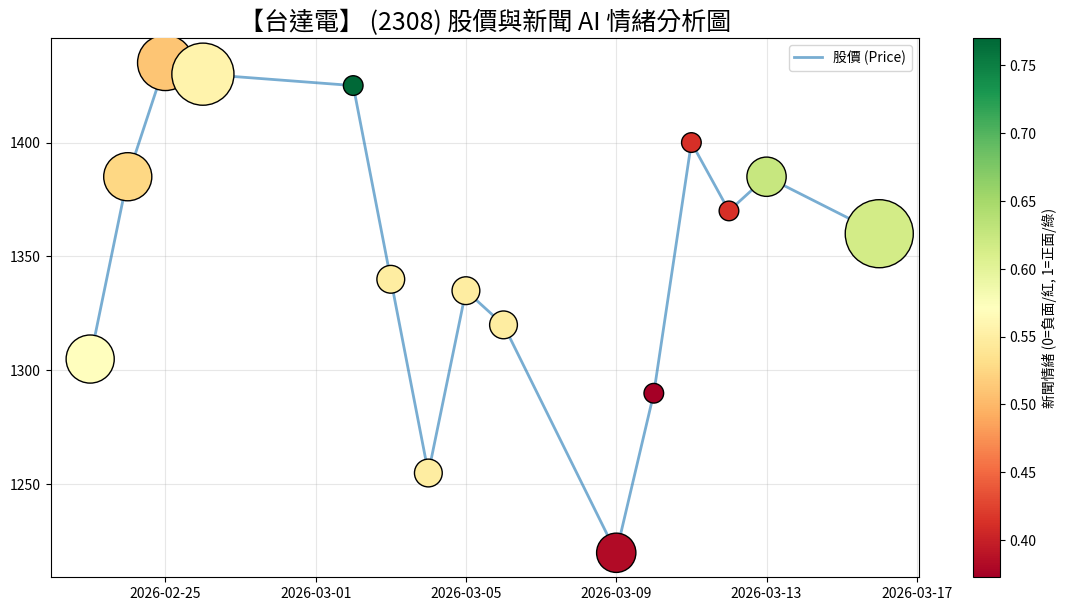


--- 📝 新聞情緒數據摘要 (前 5 筆) ---
           日期                                               新聞標題   AI 情緒分數
0  2026-03-11   【Hot台股】台達電暴衝重返1400元大關！網嗨「要亮燈」 分析師曝布局時機 - Yahoo股市  0.411940
1  2026-03-16  【即時新聞】最新輝達GTC大會重磅登場！受惠AI題材台達電今日股價強勢開高 - CMoney...  0.932582
2  2026-03-13  杜金龍8點45分搶進台積電、台達電狂賺百元！旺宏、群創、鴻海可以撿？當沖秘訣曝光！看好這檔金...  0.646878
3  2026-03-13                             台達電逆勢上漲顯韌性 - cmoney.tw  0.566166
4  2026-03-16      台股震盪像洗三溫暖！杜金龍按讚台積電、台達電還看好這檔金融股衝破百元- 證券 - 工商時報  0.867718


In [10]:
# 1. 安裝所需套件 (新增 transformers 深度學習套件)
!pip install -q yfinance feedparser transformers torch

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from datetime import datetime, timedelta
import feedparser
import time
import sys

# 引入 Hugging Face 的 AI 模型處理套件
from transformers import pipeline

# ==========================================
# 🔧 0. 環境準備：修復 Colab 中文字型亂碼問題
# ==========================================
print("📥 正在下載並設定繁體中文字型 (思源黑體)...")
# 從 Google 開源字型庫下載字型檔
!wget -q -O NotoSansTC.otf https://raw.githubusercontent.com/googlefonts/noto-cjk/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf

# 載入字型到 matplotlib
fm.fontManager.addfont("NotoSansTC.otf")
font_prop = fm.FontProperties(fname="NotoSansTC.otf")
plt.rcParams['font.sans-serif'] = [font_prop.get_name()] # 設定預設字型
plt.rcParams['axes.unicode_minus'] = False               # 修正負號顯示問題

# ==========================================
# ⚙️ 1. 設定參數區 (全域變數 Single Source of Truth)
# ==========================================
stock_id = "2308"
stock_name = "台達電"

# ==========================================
# 📈 2. 智慧抓取股價與判定市場別
# ==========================================
print(f"🔍 開始搜尋股票代號: {stock_id} ...")

market_type = ""
ticker_id = ""
df_price = pd.DataFrame()

df_tw = yf.download(f"{stock_id}.TW", period="1mo", progress=False)
if not df_tw.empty:
    market_type = "上市 (TSE)"
    ticker_id = f"{stock_id}.TW"
    df_price = df_tw
else:
    df_two = yf.download(f"{stock_id}.TWO", period="1mo", progress=False)
    if not df_two.empty:
        market_type = "上櫃 / 興櫃 (OTC / Emerging)"
        ticker_id = f"{stock_id}.TWO"
        df_price = df_two

if df_price.empty:
    print(f"\n❌ [錯誤] 查無此股票價格！(代號: {stock_id})")
    sys.exit("程式已終止。")

print(f"✅ 成功獲取股價資料！(市場別: {market_type})")

if isinstance(df_price.columns, pd.MultiIndex):
    df_price = df_price['Close']
else:
    df_price = df_price[['Close']]
df_price.index = pd.to_datetime(df_price.index).tz_localize(None)

# ==========================================
# 📰 3. 抓取新聞 (Google RSS)
# ==========================================
news_list = []
print(f"\n📰 開始嘗試透過 Google RSS 獲取【{stock_name}】的新聞 ...")

rss_url = f"https://news.google.com/rss/search?q={stock_name}&hl=zh-TW&gl=TW&ceid=TW:zh-Hant"
feed = feedparser.parse(rss_url)

for entry in feed.entries:
    try:
        dt_struct = entry.published_parsed
        dt = datetime.fromtimestamp(time.mktime(dt_struct))

        if dt.weekday() == 5:
            dt = dt + timedelta(days=2)
        elif dt.weekday() == 6:
            dt = dt + timedelta(days=1)

        news_list.append({'date': dt.strftime('%Y-%m-%d'), 'title': entry.title})
    except:
        continue

if not news_list:
    print(f"⚠️ 沒抓到關於【{stock_name}】的新聞。")
else:
    df_news = pd.DataFrame(news_list)
    print(f"✅ 成功取得 {len(df_news)} 則新聞")

    # ==========================================
    # 🧠 4. 使用進階 AI 模型進行情緒分析 (BERT)
    # ==========================================
    print("⏳ 載入進階 AI 語意分析模型中 (首次執行約需 15 秒)...")
    # 使用 Hugging Face 的輕量級多語系情緒模型
    sentiment_analyzer = pipeline(
        "sentiment-analysis",
        model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
        device=-1 # 強制使用 CPU
    )

    # 建立一個轉換函數 (類似 Java 的 Helper Method)
    # 模型會回傳 label ('positive', 'negative', 'neutral') 和 score (信心水準)
    def analyze_sentiment(text):
        try:
            # 擷取前 512 個字元以符合模型限制
            result = sentiment_analyzer(text[:512])[0]
            label = result['label']
            score = result['score']

            # 將結果映射回 0.0 ~ 1.0 的區間，以符合我們的泡泡圖顏色邏輯
            if label == 'positive':
                return score            # 偏向 1.0 (綠色)
            elif label == 'negative':
                return 1.0 - score      # 偏向 0.0 (紅色)
            else:
                return 0.5              # 中立 0.5 (黃色)
        except Exception as e:
            return 0.5

    print("🧠 正在逐筆分析新聞情緒...")
    df_news['sentiment'] = df_news['title'].apply(analyze_sentiment)

    daily_news = df_news.groupby('date').agg({'sentiment': ['mean', 'count']})
    daily_news.columns = ['avg_sentiment', 'news_count']
    daily_news.index = pd.to_datetime(daily_news.index)

    # 合併股價與新聞資料
    final_df = pd.merge_asof(df_price.sort_index(), daily_news.sort_index(),
                             left_index=True, right_index=True,
                             direction='backward')

    final_df['news_count'] = final_df['news_count'].fillna(0)
    final_df['avg_sentiment'] = final_df['avg_sentiment'].fillna(0.5)

    # ==========================================
    # 🎨 5. 繪圖與呈現 (支援全中文顯示)
    # ==========================================
    fig, ax1 = plt.subplots(figsize=(14, 7))
    ax1.plot(final_df.index, final_df.iloc[:, 0], color='#1f77b4', label='股價 (Price)', linewidth=2, alpha=0.6)

    # 畫出情緒泡泡
    news_days = final_df[final_df['news_count'] > 0]
    if not news_days.empty:
        scatter = ax1.scatter(news_days.index, news_days.iloc[:, 0],
                              c=news_days['avg_sentiment'], cmap='RdYlGn',
                              s=news_days['news_count'] * 200,
                              edgecolors='black', linewidth=1, zorder=5)
        cbar = plt.colorbar(scatter, ax=ax1)
        cbar.set_label('新聞情緒 (0=負面/紅, 1=正面/綠)')

    # 標題完美顯示中文！
    plt.title(f"【{stock_name}】 ({stock_id}) 股價與新聞 AI 情緒分析圖", fontsize=18, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\n--- 📝 新聞情緒數據摘要 (前 5 筆) ---")
    # 將欄位名稱改成中文，方便閱讀
    df_news_display = df_news.rename(columns={'date': '日期', 'title': '新聞標題', 'sentiment': 'AI 情緒分數'})
    print(df_news_display.head())